In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [2, 3, 4, 0, 1, 5]])

data = pd.read_csv("latency.csv")
data["Speedup"] = 0

models = set(data["Model"])
passes = set(data["Pass"])
frameworks = set(data["Framework"])
base_framework = "Nabla (Recompute)"

In [2]:
for model in models:
    for pas in passes:
        base = data.loc[
            (data["Model"] == model) & 
            (data["Pass"] == pas) & 
            (data["Framework"] == base_framework), 
            "Time"
        ].item()
        for framework in frameworks:
            time = data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Time"
            ].item()
            data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Speedup"
            ] = base / time
            
gradient_data = data[data["Pass"] == "Gradient"]
total_data = data[data["Pass"] == "Total"]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


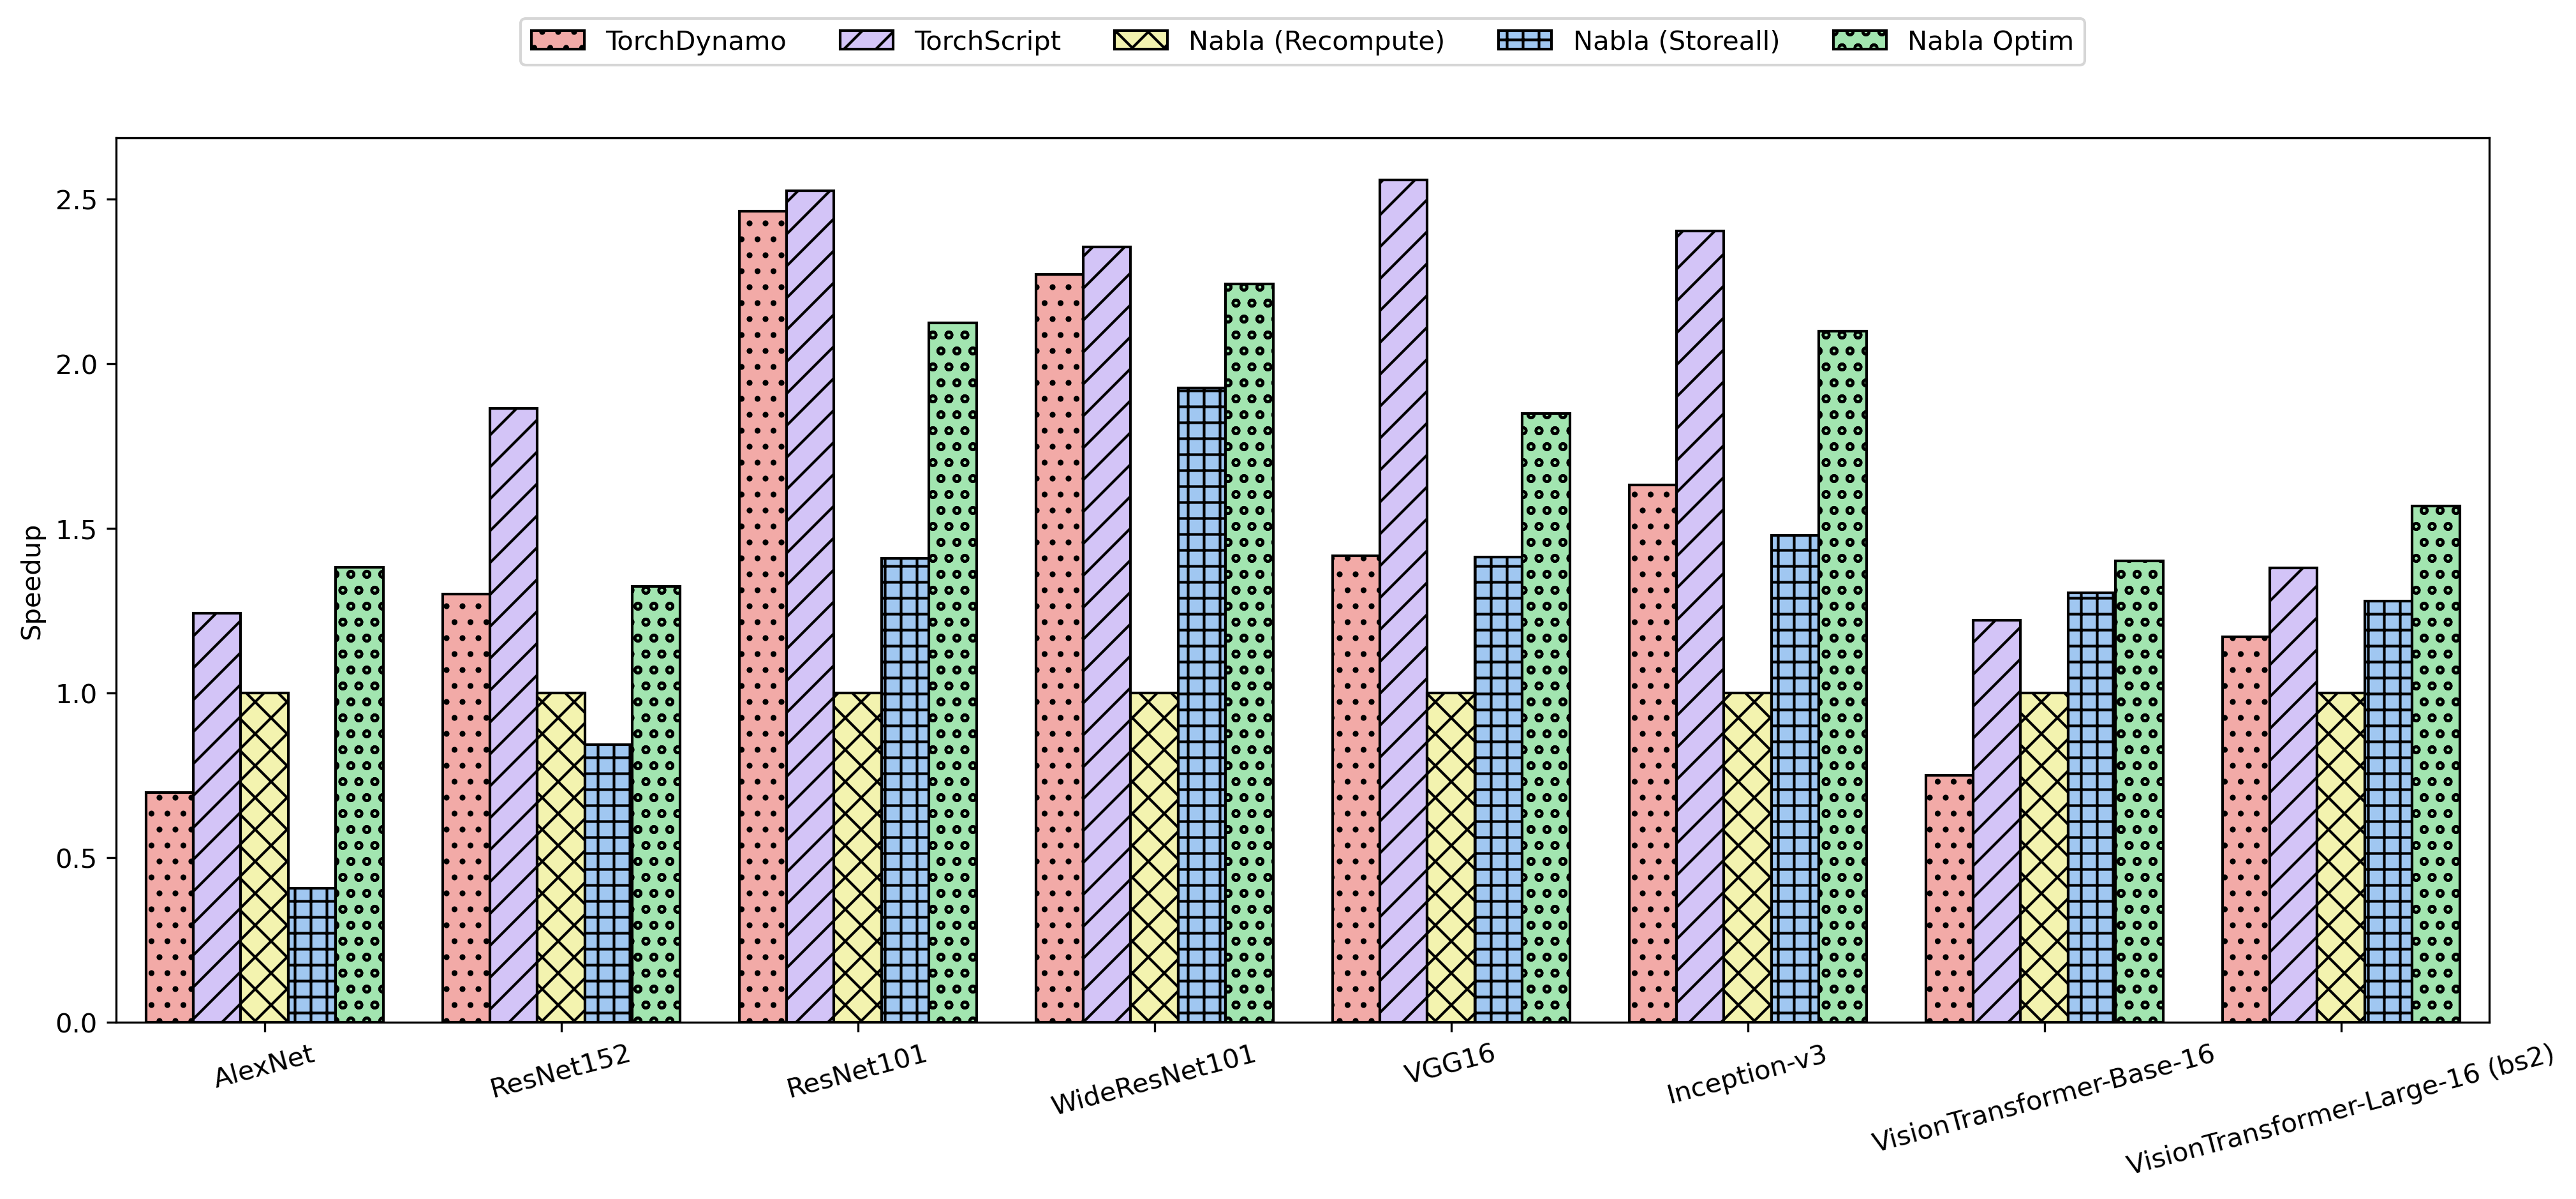

In [3]:
plt.rcParams["figure.figsize"] = (len(models) * 2, 6)

hatches = ["//", "xx", "++", "oo", ".."]
assert len(hatches) == len(frameworks)

barplot = sns.barplot(gradient_data[gradient_data, x="Model", y="Speedup", hue="Framework")
plt.xticks(rotation=15)
plt.xlabel(None)

for i, bar in enumerate(barplot.patches):
    print(i)
    bar.set_hatch(hatches[i // len(models)-1])
    bar.set_edgecolor("black")
    
legend = plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.15))

# plt.savefig("gradient.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


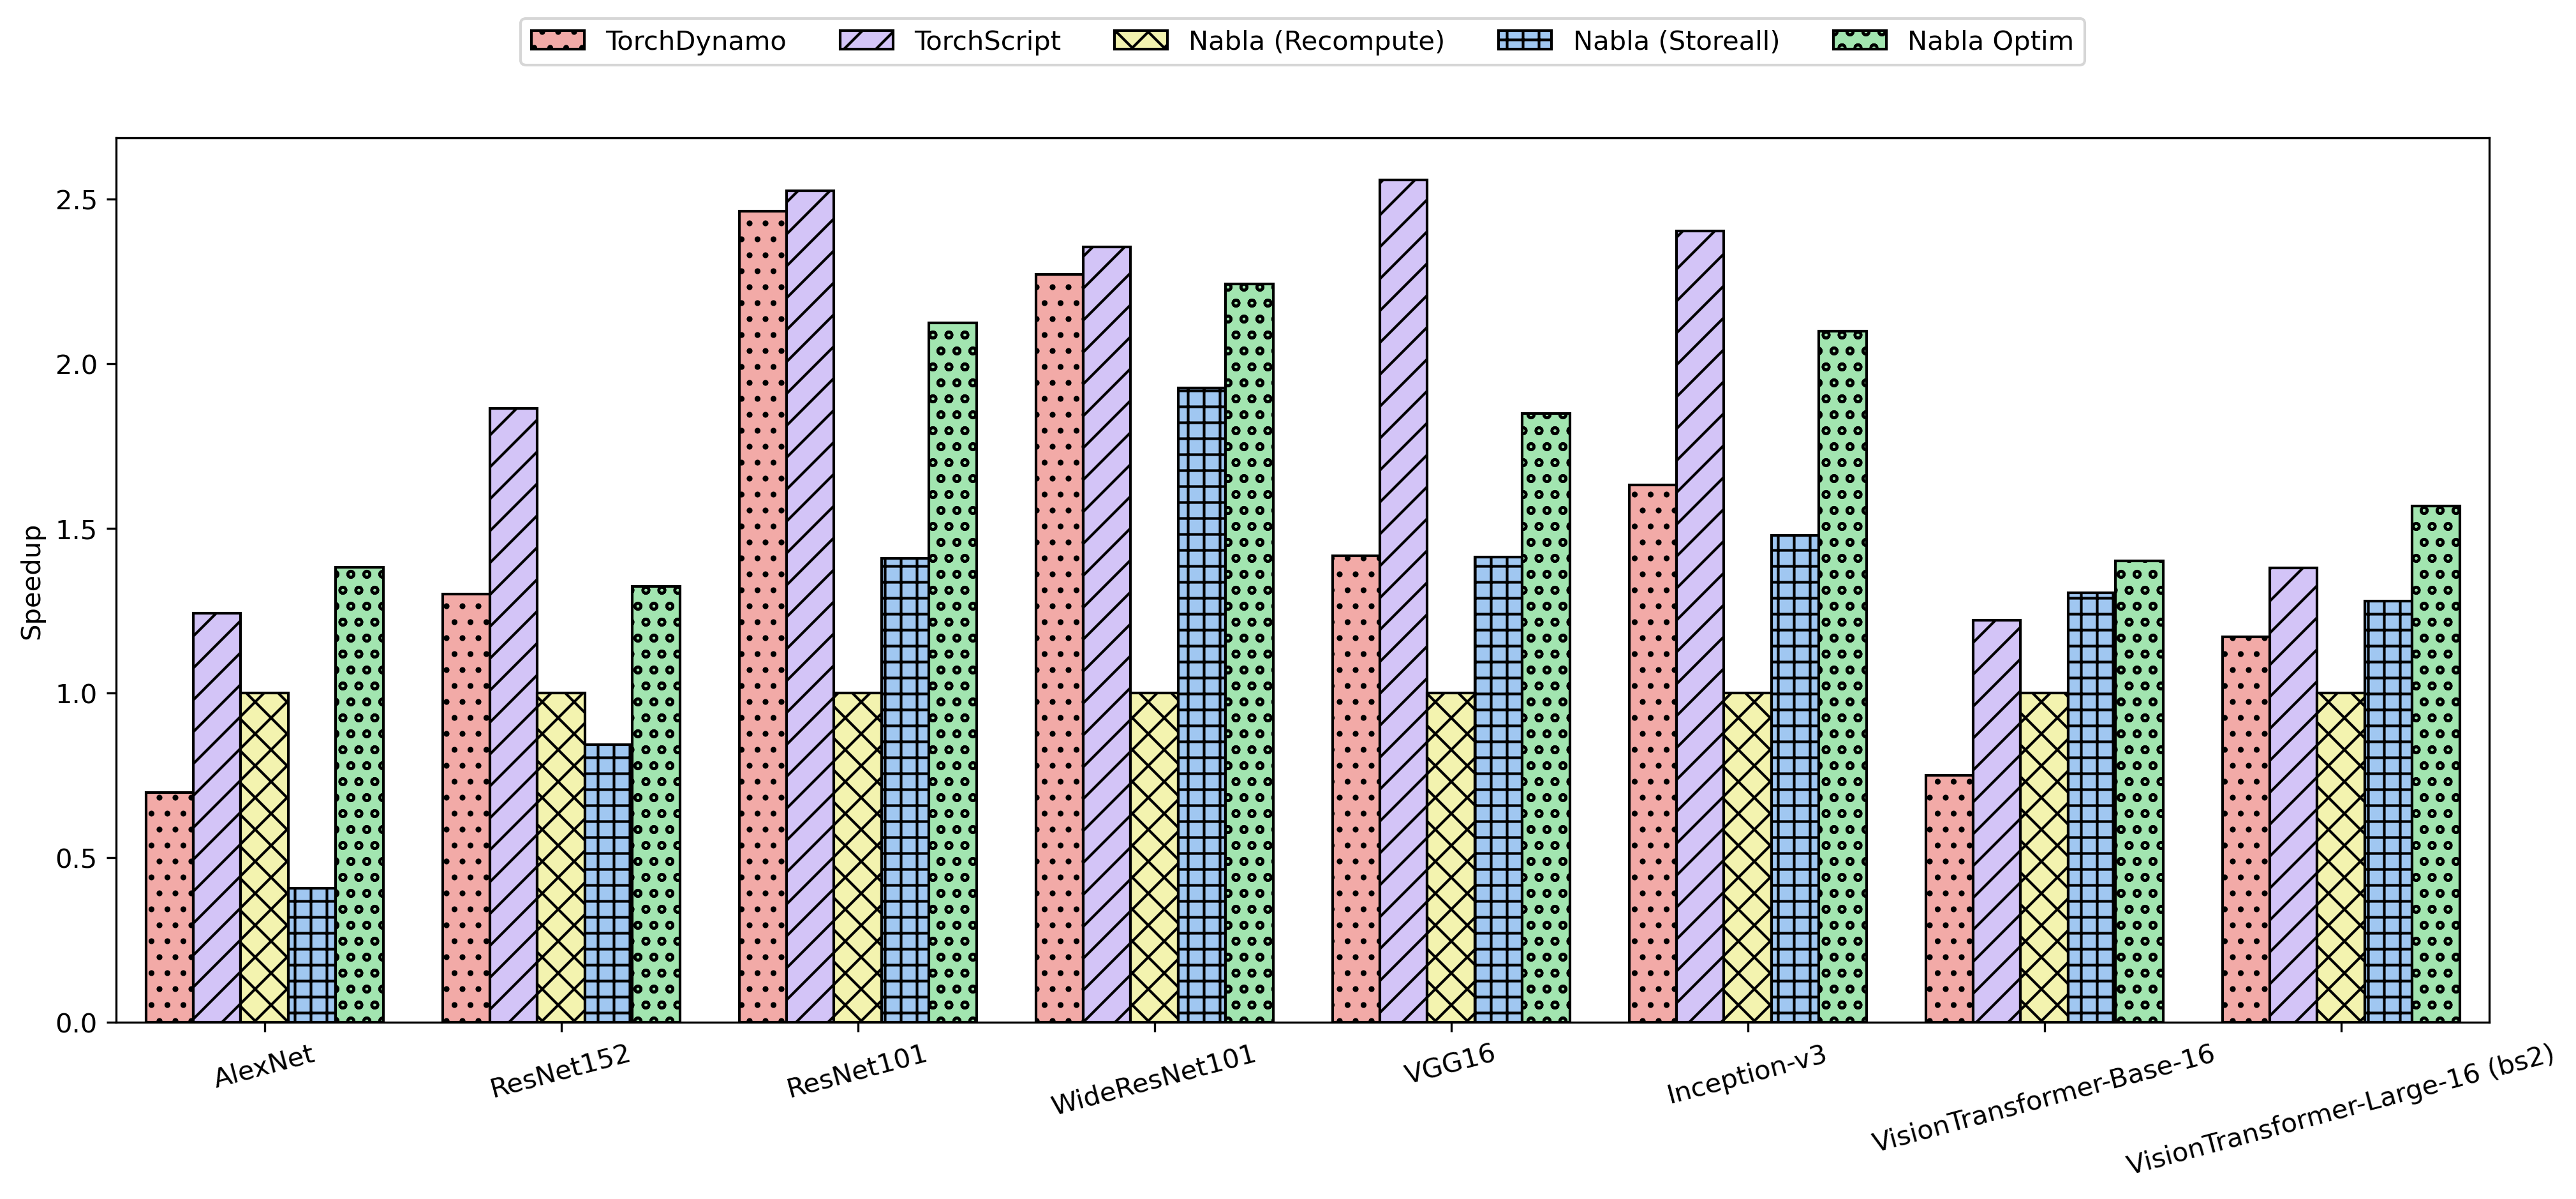

In [4]:
plt.rcParams["figure.figsize"] = (len(models) * 2, 6)

hatches = ["//", "xx", "++", "oo", ".."]
assert len(hatches) == len(frameworks)

barplot = sns.barplot(gradient_data, x="Model", y="Speedup", hue="Framework", edgecolor="black")
plt.xticks(rotation=15)
plt.xlabel(None)

for i, bar in enumerate(barplot.patches):
    print(i)
    bar.set_hatch(hatches[i // len(models)-1])
    bar.set_edgecolor("black")
    
legend = plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.15))

# plt.savefig("gradient.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

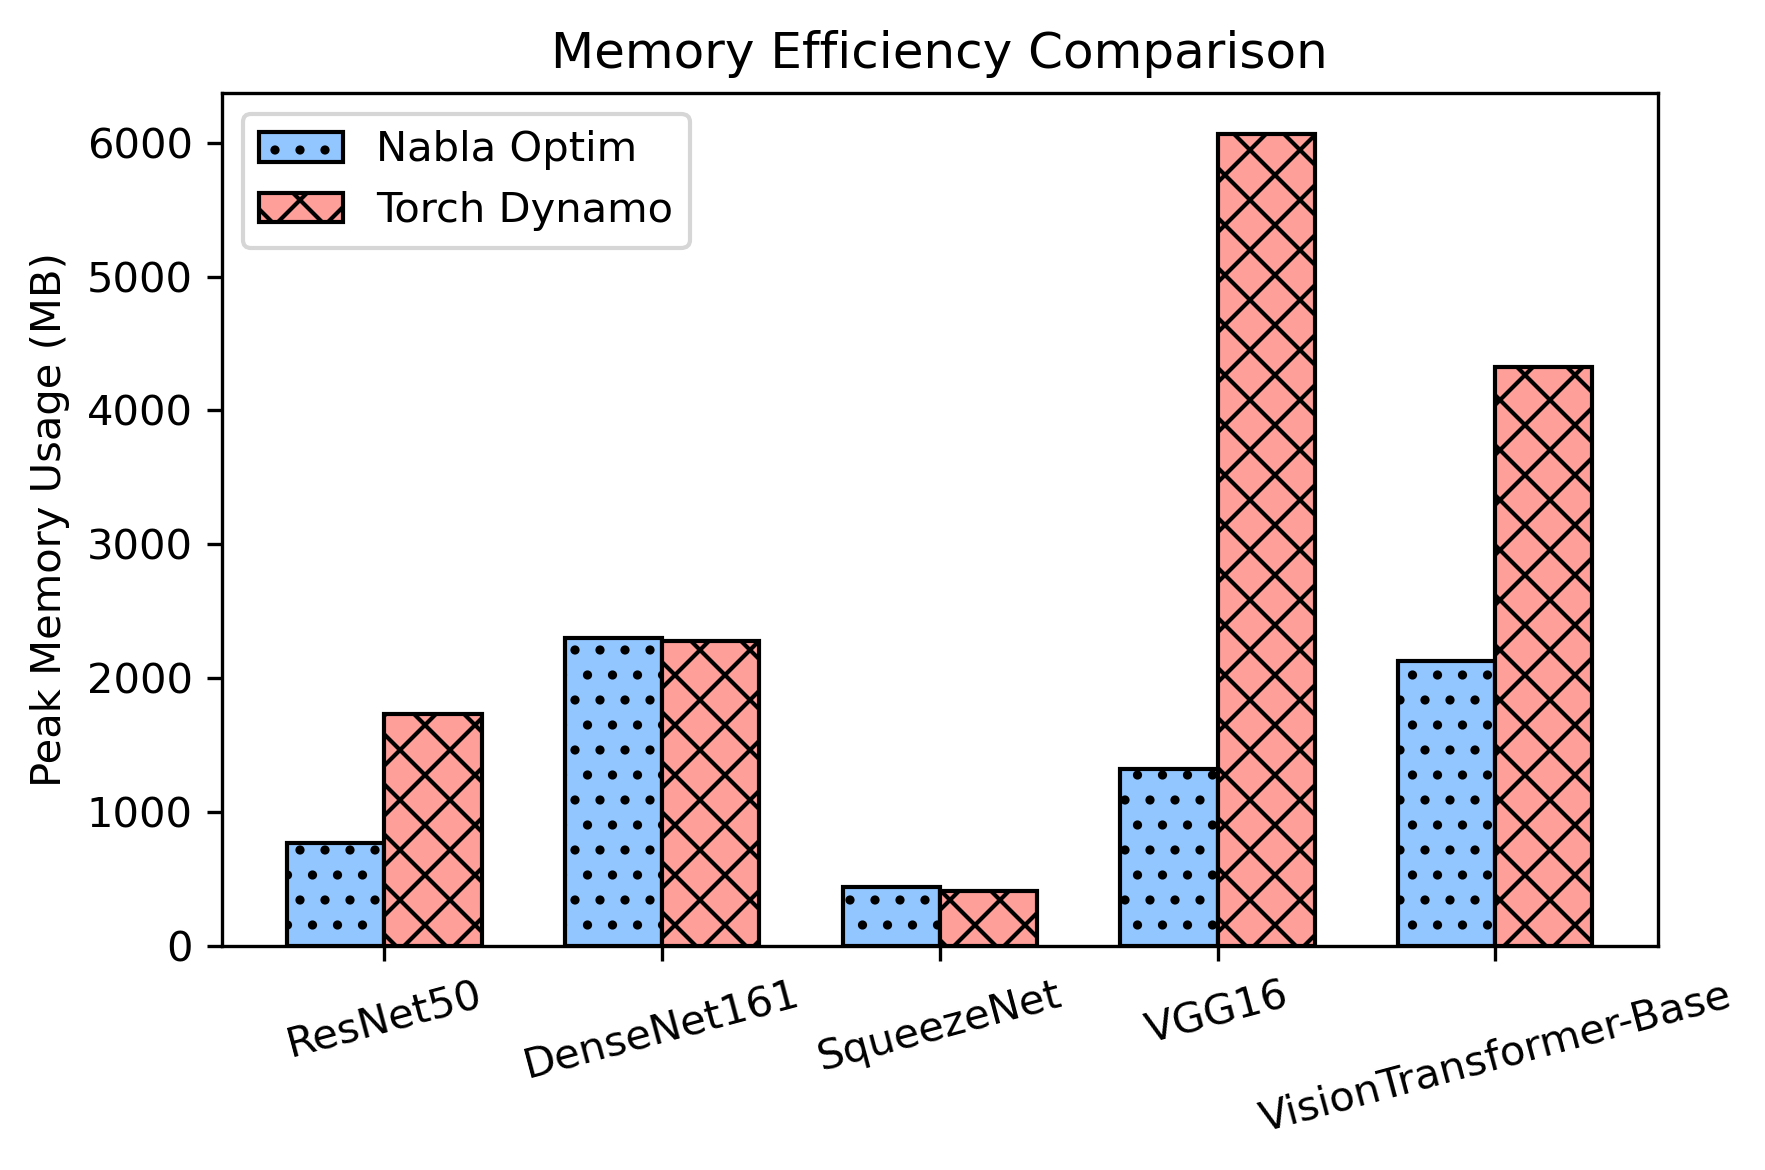

In [5]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [0, 2, 4, 1, 3, 5]])

# Model names
models = ['ResNet50', 'DenseNet161', 'SqueezeNet', 'VGG16', 'VisionTransformer-Base']

# Defining the data
models = ['ResNet50', 'DenseNet161', 'SqueezeNet', 'VGG16', 'VisionTransformer-Base']
nabla_optim_scores = [771.5, 2303.5, 438.9, 1326.3, 2131.1]
torch_dynamo_scores = [1731.5, 2275.8, 416.2, 6066.6, 4323.2]

# Setting the positions and width for the bars
positions = np.arange(len(models))
bar_width = 0.35

# Creating the plot
fig, ax = plt.subplots(figsize=(6, 4))  # Adjusting the figure size for better visibility

fig.set_edgecolor('black')

# Plotting the data
bars_nabla_optim = ax.bar(positions - bar_width/2, nabla_optim_scores, bar_width, label='Nabla Optim', hatch="..", edgecolor="black")
bars_torch_dynamo = ax.bar(positions + bar_width/2, torch_dynamo_scores, bar_width, label='Torch Dynamo', hatch="xx", edgecolor="black")

# Adding some final touches
ax.set_xticks(positions)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('Peak Memory Usage (MB)')
ax.set_title('Memory Efficiency Comparison')
ax.legend()
ax.grid(False)
ax.set_facecolor('white')  # Ensuring the background is white

# Ensuring the plot itself has a black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# Displaying the plot
plt.tight_layout()
#plt.show()
plt.savefig("mem-comparison.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)